# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

  Using cached plotly-6.3.1-py3-none-any.whl.metadata (8.5 kB)
  Using cached narwhals-2.6.0-py3-none-any.whl.metadata (11 kB)
Using cached plotly-6.3.1-py3-none-any.whl (9.8 MB)
Using cached narwhals-2.6.0-py3-none-any.whl (408 kB)
  Attempting uninstall: plotly━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [narwhals]
    Found existing installation: plotly 5.24.1━━━━ 0/2 [narwhals]
    Uninstalling plotly-5.24.1:━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [plotly]
      Successfully uninstalled plotly-5.24.1m╺━━━━━━━━━━━━━━━━━━━ 1/2 [plotly]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]━━━━ 1/2 [plotly]

[notice] A new release of pip is available: 20.3.4 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [18]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [19]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [31]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [21]:
median_household_income = df_hh_income.shape
pct_people_below_pov = df_pct_poverty.shape
pct_completed_high_school = df_pct_completed_hs.shape
share_race_by_city = df_share_race_city.shape
death_by_police = df_fatalities.shape
print(f"first dataset: {median_household_income}")
print(f"second dataset: {pct_people_below_pov}")
print(f"third dataset: {pct_completed_high_school}")
print(f"fourth dataset: {share_race_by_city}")
print(f"fifth dataset: {death_by_police}")

first dataset: (29322, 3)
second dataset: (29329, 3)
third dataset: (29329, 3)
fourth dataset: (29268, 7)
fifth dataset: (2535, 14)


In [22]:
nbr_col_houseld_income = df_hh_income.columns.tolist()
nbr_col_people_bel_pov = df_pct_poverty.columns.tolist()
nbr_col_pct_completed_hs = df_pct_completed_hs.columns.tolist()
nbr_col_share_race = df_share_race_city.columns.tolist()
nbr_death = df_fatalities.columns.tolist()
print(f"first dataset: {nbr_col_houseld_income}")
print(f"second dataset: {nbr_col_people_bel_pov}")
print(f"third dataset: {nbr_col_pct_completed_hs}")
print(f"fourth dataset: {nbr_col_share_race}")
print(f"fifth dataset: {nbr_death}")

first dataset: ['Geographic Area', 'City', 'Median Income']
second dataset: ['Geographic Area', 'City', 'poverty_rate']
third dataset: ['Geographic Area', 'City', 'percent_completed_hs']
fourth dataset: ['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
fifth dataset: ['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']


In [23]:
# Check for NaN
if df_hh_income.isna().any().any() == True:
    print(f"NaN values exist in dataset1")
if df_pct_poverty.isna().any().any() == True:
    print(f"NAN values exist in dataset2")
if df_pct_completed_hs.isna().any().any() == True:
    print(f"NAN values exist in dataset3")
if df_share_race_city.isna().any().any():
    print(f"NAN values exist in dataset4")
if df_fatalities.isna().any().any() == True:
    print(f"NAN values exist in dataset5")

NaN values exist in dataset1
NAN values exist in dataset5


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [24]:
df_hh_income = df_hh_income.fillna(0)

In [25]:
df_fatalities = df_fatalities.fillna(0)

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [26]:
%pip install us


[notice] A new release of pip is available: 20.3.4 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


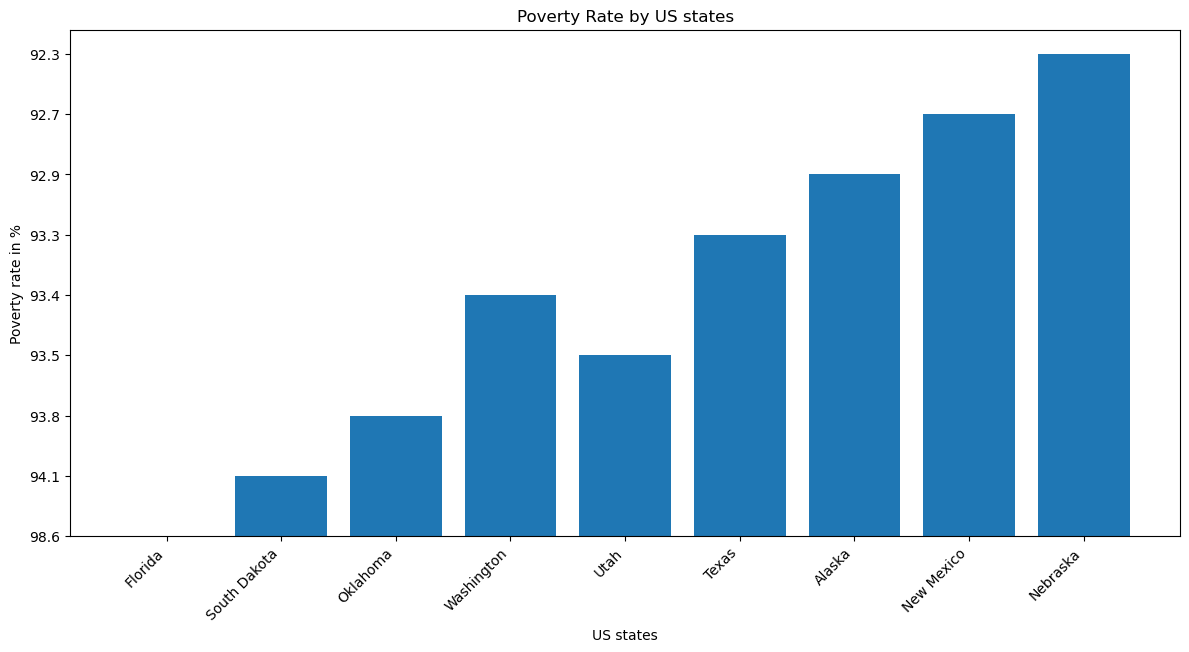

In [27]:
df_pct_poverty.head()
clean_poverty_data = df_pct_poverty.sort_values(["poverty_rate"], ascending=False)
def apply_state_name(code):
    """get correct states name"""
    import us
    states = us.states.lookup(code)
    return states.name if states else "UT"
clean_poverty_data["States"] = clean_poverty_data["Geographic Area"].apply(apply_state_name)
top_10_states = clean_poverty_data.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_states["States"], top_10_states["poverty_rate"])
plt.title("Poverty Rate by US states")
plt.xlabel("US states")
plt.ylabel("Poverty rate in %")
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

In [14]:
"""Nebraska was the US state with the highest poverty rate"""

'Nebraska was the US state with the highest poverty rate'

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [36]:
import pandas
import us
df_pct_completed_hs = pd.read_csv("Pct_Over_25_Completed_High_School.csv", encoding="latin1")

completed_highschool = df_pct_completed_hs.fillna(0)
completed_highschool = completed_highschool.sort_values(
    by="percent_completed_hs",
    ascending=True
)

def apply_state_name(code):
    """get correct states name"""
    import us
    states = us.states.lookup(code)
    return states.name if states else "UT"

completed_highschool["States"] = completed_highschool["Geographic Area"].apply(apply_state_name)
completed_highschool

,Geographic Area,City,percent_completed_hs,States
14024,MO,Goss town,-,Missouri
770,AK,Loring CDP,-,Alaska
14570,MO,Tarrants village,-,Missouri
1113,AZ,Hunter Creek CDP,-,Arizona
16280,NJ,Ross Corner CDP,-,New Jersey
...,...,...,...,...
7176,IL,Scott AFB CDP,99.8,Illinois
26212,TX,West Lake Hills city,99.8,Texas
23070,PA,Toftrees CDP,99.8,Pennsylvania
25983,TX,Serenada CDP,99.9,Texas


In [37]:
"""The state with the lowest graduation rate for high school is Missouri and the highest Hawaii"""

'The state with the lowest graduation rate for high school is Missouri and the highest Hawaii'

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).